## Lab 1 - Bag Price Prediction
### Machine Learning with Random Forest Regressor

In [1]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print('Libraries loaded successfully!')

Libraries loaded successfully!


## Step 2: Load and Explore Dataset

In [2]:
# Load the bag price dataset
df = pd.read_csv('Noisy_Student_Bag_Price_Prediction_Dataset.csv')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Dataset shape: (52500, 10)
Columns: ['Brand', 'Material', 'Size', 'Compartments', 'Laptop Compartment', 'Waterproof', 'Style', 'Color', 'Weight Capacity (kg)', 'Price']


In [3]:
# Preview first few rows
df.head()

,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,Jansport,Nylon,Small,2.0,No,Yes,Backpack,Green,13.340058,143.445135
1,Under Armour,Nylon,Large,4.0,Yes,Yes,Tote,Pink,5.918030,72.086319
2,Nike,Nylon,Large,NaN,No,Yes,Messenger,Red,24.088386,29.699631
3,Nike,Nylon,Small,1.0,Yes,No,Messenger,Pink,5.000000,27.181990
4,Under Armour,Leather,Small,8.0,Yes,No,NaN,Black,11.258172,71.953236


In [4]:
# Check missing values
print('Missing values per column:')
print(df.isnull().sum())

# Target variable summary
target_col = 'Price'
print(f'\nPrice Summary:')
print(f'  Average : ${df[target_col].mean():.2f}')
print(f'  Min     : ${df[target_col].min():.2f}')
print(f'  Max     : ${df[target_col].max():.2f}')

Missing values per column:
Brand                   2625
Material                2625
Size                    2625
Compartments            2625
Laptop Compartment      2625
Waterproof              2625
Style                   2625
Color                   2625
Weight Capacity (kg)    2625
Price                   2625
dtype: int64

Price Summary:
  Average : $81.92
  Min     : $15.00
  Max     : $150.00


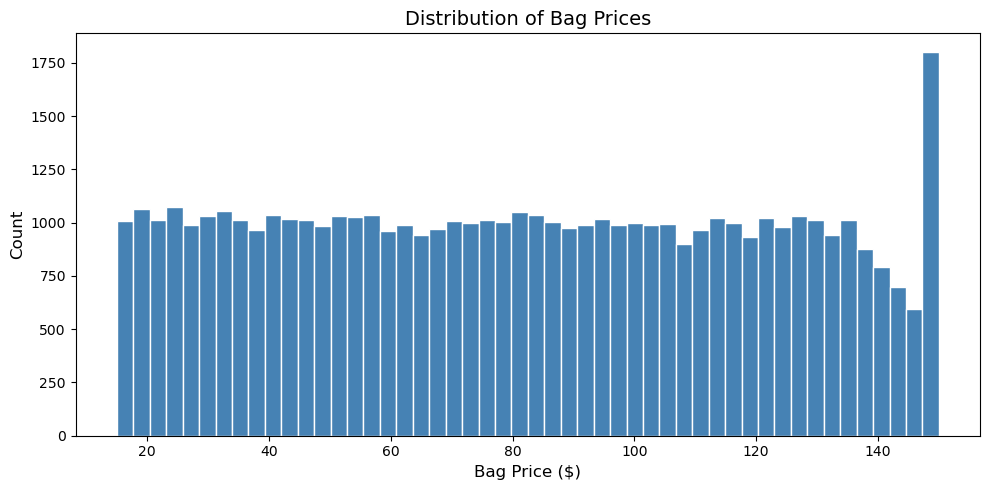

In [5]:
# Visualize price distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['Price'].dropna(), bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('Bag Price ($)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Bag Prices', fontsize=14)
plt.tight_layout()
plt.show()

## Step 3: Data Preprocessing

In [6]:
# Drop rows with missing values
df_clean = df.dropna().reset_index(drop=True)
print(f'After removing missing rows: {df_clean.shape}')

# Encode categorical columns
cat_cols = ['Brand', 'Material', 'Size', 'Laptop Compartment', 'Waterproof', 'Style', 'Color']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    le_dict[col] = le

print('Label encoding complete!')

After removing missing rows: (31363, 10)
Label encoding complete!


## Step 4: Feature Selection & Train/Test Split

In [7]:
# Define features and target
target_col = 'Price'
feature_cols = [c for c in df_clean.columns if c != target_col]

X_all = df_clean[feature_cols]
y_all = df_clean[target_col]

print(f'Feature matrix shape : {X_all.shape}')
print(f'Target vector shape  : {y_all.shape}')

# 80/20 train-validation split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)
print(f'Training samples     : {X_tr.shape[0]}')
print(f'Validation samples   : {X_val.shape[0]}')

Feature matrix shape : (31363, 9)
Target vector shape  : (31363,)
Training samples     : 25090
Validation samples   : 6273


## Step 5: Train Random Forest Model

In [8]:
# Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

print('Training model...')
rf_model.fit(X_tr, y_tr)
print('Done! Model trained successfully.')

Training model...
Done! Model trained successfully.


## Step 6: Model Evaluation

In [9]:
# Evaluate on validation set
val_predictions = rf_model.predict(X_val)
mae_score = mean_absolute_error(y_val, val_predictions)
avg_price = y_val.mean()

print(f'Validation MAE       : ${mae_score:.2f}')
print(f'Avg Validation Price : ${avg_price:.2f}')
print(f'MAE as % of Average  : {mae_score/avg_price*100:.2f}%')

Validation MAE       : $33.91
Avg Validation Price : $81.73
MAE as % of Average  : 41.49%


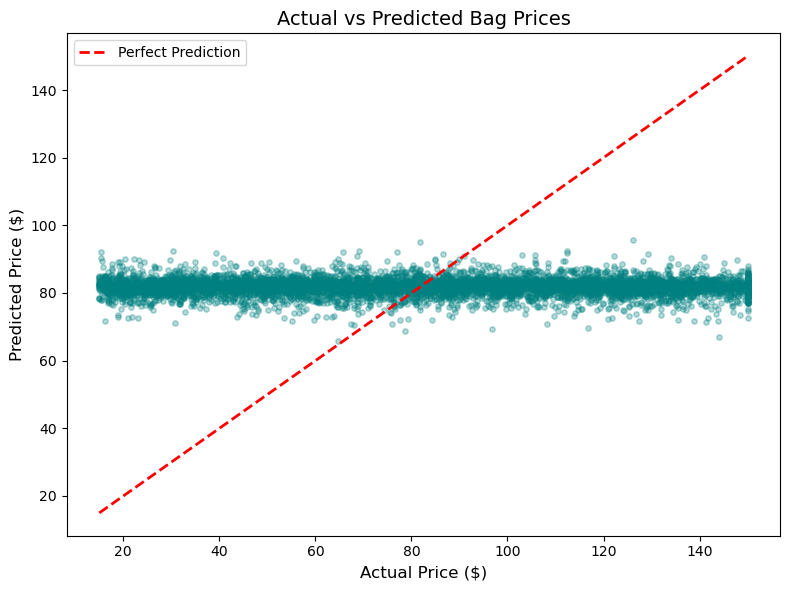

In [10]:
# Plot Actual vs Predicted
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_val, val_predictions, alpha=0.3, color='teal', s=15)
mn, mx = y_val.min(), y_val.max()
ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Price ($)', fontsize=12)
ax.set_ylabel('Predicted Price ($)', fontsize=12)
ax.set_title('Actual vs Predicted Bag Prices', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

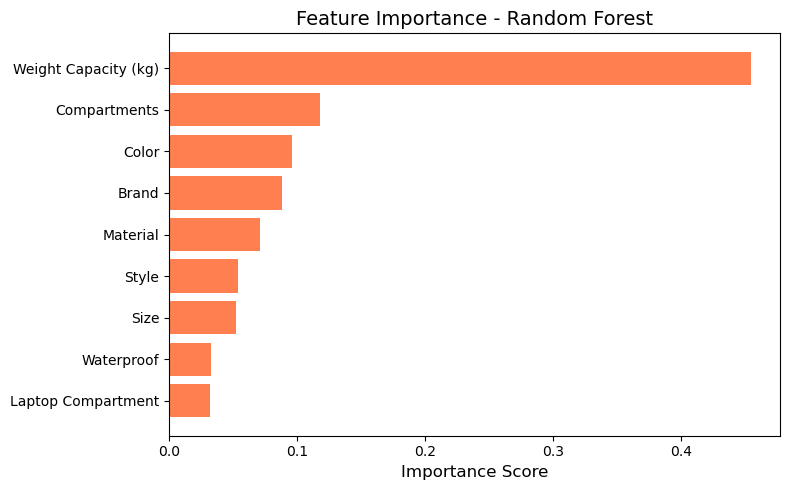

             Feature  Importance
Weight Capacity (kg)    0.454520
        Compartments    0.117991
               Color    0.096444
               Brand    0.088480
            Material    0.070777
               Style    0.054111
                Size    0.052726
          Waterproof    0.033130
  Laptop Compartment    0.031822


In [11]:
# Feature importance
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1], color='coral')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Feature Importance - Random Forest', fontsize=14)
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

## Step 7: Generate Final Predictions & Save Submission

In [12]:
# Retrain on complete cleaned dataset
final_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
final_rf.fit(X_all, y_all)
print('Final model trained on full dataset!')

# Generate predictions on held-out test set
df_test = pd.read_csv('test.csv')
X_test_final = df_test[feature_cols]
test_preds = final_rf.predict(X_test_final)

# Build submission file
output_df = pd.DataFrame({'Id': range(1, len(test_preds)+1), 'Price': test_preds})
output_df.to_csv('submission.csv', index=False)
print('Submission file saved: submission.csv')
print(output_df.head())

Final model trained on full dataset!
Submission file saved: submission.csv
   Id      Price
0   1  85.693577
1   2  82.802810
2   3  84.938314
3   4  85.077559
4   5  83.143005
